In [ ]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem.rdMolDescriptors import GetMorganFingerprintAsBitVect
from rdkit.Chem import rdMolDescriptors
from rdkit.DataStructs import ConvertToNumpyArray
from rdkit.Chem import AllChem, Descriptors
from rdkit.DataStructs import ExplicitBitVect, TanimotoSimilarity
from sklearn.cluster import KMeans, SpectralClustering, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from yellowbrick.cluster import KElbowVisualizer
import pandas as pd

# Define file paths
synthetic_data_path = "/homes/mesmaeili/Documents/DS6/data/non_natural_products.txt"  
natural_data_path = "/homes/mesmaeili/Documents/DS6/data/subset_natural_products.txt"

try:
    # Load the datasets
    synthetic_df = pd.read_csv(synthetic_data_path, sep="\t", engine='python')
    natural_df = pd.read_csv(natural_data_path, sep="\t", engine='python')
    
    # Add a column to indicate source: 1 for synthetic, 0 for natural
    synthetic_df['source'] = 1
    natural_df['source'] = 0
    
    # Combine the datasets
    combined_df = pd.concat([synthetic_df, natural_df], ignore_index=True)
    
    # Display the combined dataset
    print(combined_df.head())
except Exception as e:
    print(f"Error loading or processing files: {e}")


In [ ]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem.SaltRemover import SaltRemover

def cleaned(dataframe, min_weight=50, max_weight=1000):
    """
    Cleans the input dataset by handling missing values, validating and canonicalizing SMILES,
    removing duplicates, filtering by molecular properties, and standardizing molecular formats.

    Args:
        dataframe (pd.DataFrame): The input dataset containing 'canonical_smiles' and optional features.
        min_weight (float): Minimum molecular weight for filtering.
        max_weight (float): Maximum molecular weight for filtering.

    Returns:
        pd.DataFrame: The cleaned dataset.
    """
    # Drop rows with missing SMILES
    dataframe = dataframe.dropna(subset=['canonical_smiles']).reset_index(drop=True)

    # Validate SMILES
    def is_valid_smiles(smiles):
        return Chem.MolFromSmiles(smiles) is not None

    dataframe['valid'] = dataframe['canonical_smiles'].apply(is_valid_smiles)
    invalid_smiles = dataframe[~dataframe['valid']]  # Log invalid SMILES for review
    invalid_smiles.to_csv('invalid_smiles.csv', index=False)
    dataframe = dataframe[dataframe['valid']].drop(columns=['valid']).reset_index(drop=True)

    # Remove duplicates
    dataframe = dataframe.drop_duplicates(subset=['canonical_smiles']).reset_index(drop=True)

    # Canonicalize SMILES
    dataframe['canonical_smiles'] = dataframe['canonical_smiles'].apply(lambda x: Chem.MolToSmiles(Chem.MolFromSmiles(x)))

    # Remove salts and standardize molecular formats
    remover = SaltRemover()
    dataframe['canonical_smiles'] = dataframe['canonical_smiles'].apply(
        lambda x: Chem.MolToSmiles(remover.StripMol(Chem.MolFromSmiles(x)))
    )

    # Filter by molecular properties (e.g., molecular weight)
    def is_within_property_range(smiles, min_weight, max_weight):
        mol = Chem.MolFromSmiles(smiles)
        if not mol:
            return False
        weight = Descriptors.MolWt(mol)
        return min_weight <= weight <= max_weight

    dataframe['valid_range'] = dataframe['canonical_smiles'].apply(
        lambda x: is_within_property_range(x, min_weight, max_weight)
    )
    dataframe = dataframe[dataframe['valid_range']].drop(columns=['valid_range']).reset_index(drop=True)

    # Normalize compound names (if available)
    if 'compound_name' in dataframe.columns:
        dataframe['compound_name'] = dataframe['compound_name'].str.lower()

    return dataframe

# Example: Applying the function to a dataset
cleaned_df = cleaned(combined_df)

# Inspect the cleaned dataset
print(cleaned_df.head())


In [94]:
# Example: Removing outliers using Z-score
from scipy.stats import zscore
combined_df = combined_df[(np.abs(zscore(combined_df.select_dtypes(include=[np.number]))) < 3).all(axis=1)]


In [ ]:
print(combined_df.dtypes)


In [ ]:
from rdkit import Chem
from rdkit.DataStructs import ConvertToNumpyArray
import numpy as np

def generate_fingerprint_embeddings(dataframe):
    """
    This function generates molecular fingerprints as embeddings for the 'canonical_smiles' column
    in the given dataframe and adds them as a new column 'fingerprint_embedding'.

    Args:
        dataframe (pd.DataFrame): Input dataframe with a 'canonical_smiles' column.

    Returns:
        pd.DataFrame: Updated dataframe with a 'fingerprint_embedding' column.
    """
    # Step 1: Convert SMILES Strings to RDKit Molecule Objects
    dataframe['rdkit_mol'] = dataframe['canonical_smiles'].apply(lambda x: Chem.MolFromSmiles(x) if x else None)

    # Step 2: Generate RDKit Fingerprints
    def compute_fingerprint(mol):
        if mol is None:
            return None
        fp = Chem.RDKFingerprint(mol)  # Generate RDKit fingerprint
        arr = np.zeros((1,), dtype=np.int32)  # Initialize a numpy array
        ConvertToNumpyArray(fp, arr)  # Convert fingerprint to numpy array
        return arr

    dataframe['fingerprint_embedding'] = dataframe['rdkit_mol'].apply(compute_fingerprint)

    # Step 3: Drop rows where fingerprint generation failed
    dataframe = dataframe.dropna(subset=['fingerprint_embedding']).reset_index(drop=True)

    return dataframe

# Example Usage
combined_df_with_embeddings = generate_fingerprint_embeddings(combined_df)

combined_df_with_embeddings.head()


In [ ]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors

# Step 1: Detect Invalid SMILES
def detect_invalid_smiles(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        return mol is not None
    except:
        return False

# Step 2: Calculate Molecular Properties
def calculate_properties(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if not mol:
        return {
            "Molecular Weight": None,
            "Heavy atoms": None,
            "logP": None,
            "Refractivity": None,
            "TPSA": None,
            "fraction csp3": None,
            "H-Bond Donors": None,
            "H-Bond Acceptors": None,
            "Rotatable bonds": None,
            "Num rings": None,
            "Aromatic Rings": None,
            "Aliphatic_rings": None,
            "Stereo centers": None,
            "Charge": None,
            "Valence electrons": None,
        }
    return {
        "Molecular Weight": Descriptors.MolWt(mol),
        "Heavy atoms": Descriptors.HeavyAtomCount(mol),
        "logP": Descriptors.MolLogP(mol),
        "Refractivity": Descriptors.MolMR(mol),
        "TPSA": rdMolDescriptors.CalcTPSA(mol),
        "fraction csp3": rdMolDescriptors.CalcFractionCSP3(mol),
        "H-Bond Donors": Descriptors.NumHDonors(mol),
        "H-Bond Acceptors": Descriptors.NumHAcceptors(mol),
        "Rotatable bonds": Descriptors.NumRotatableBonds(mol),
        "Num rings": rdMolDescriptors.CalcNumRings(mol),
        "Aromatic Rings": rdMolDescriptors.CalcNumAromaticRings(mol),
        "Aliphatic_rings": rdMolDescriptors.CalcNumAliphaticRings(mol),
        "Stereo centers": len(Chem.FindMolChiralCenters(mol, includeUnassigned=True)),
        "Charge": Chem.rdmolops.GetFormalCharge(mol),
        "Valence electrons": Descriptors.NumValenceElectrons(mol),
    }

# Step 3: Generate Morgan Fingerprints
def get_fingerprint(smiles, radius=2, n_bits=1024):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        return np.array(rdMolDescriptors.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits))
    else:
        return np.zeros(n_bits, dtype=int)


# Apply functions to the dataset
def process_dataset(dataframe):
    # Detect invalid SMILES
    dataframe['valid'] = dataframe['canonical_smiles'].apply(detect_invalid_smiles)

    # Filter valid SMILES
    valid_df = dataframe[dataframe['valid']].reset_index(drop=True)

    # Calculate molecular properties
    properties_df = valid_df['canonical_smiles'].apply(calculate_properties)
    properties_expanded = pd.DataFrame(properties_df.tolist())

    # Generate fingerprints
    valid_df['Fingerprint'] = valid_df['canonical_smiles'].apply(get_fingerprint)
    fingerprint_matrix = pd.DataFrame(valid_df['Fingerprint'].tolist(), index=valid_df.index)

    # Combine all features into one DataFrame
    final_df = pd.concat([valid_df.drop(columns=['Fingerprint']), properties_expanded, fingerprint_matrix], axis=1)

    return final_df

# Example Usage
processed_df = process_dataset(combined_df)

# Display results
print(processed_df.head())


In [ ]:
def prepare_numerical_data(dataframe):
    """
    Prepares the dataset for clustering by keeping only numerical columns.
    Optionally sets 'molecular_formula' as the index for better reference.
    
    Args:
        dataframe (pd.DataFrame): The cleaned dataset.
        
    Returns:
        pd.DataFrame: A DataFrame with only numerical columns, indexed by 'molecular_formula'.
    """
    # Set molecular_formula as index (optional)
    dataframe = dataframe.set_index('molecular_formula')

    # Keep only numerical columns
    numerical_df = dataframe.select_dtypes(include=[np.number])

    return numerical_df

# Example: Prepare the dataset for clustering
numerical_data = prepare_numerical_data(processed_df)

# Inspect the processed data
print(numerical_data.head())


In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

def prepare_features(df):
    # Convert all column names to strings
    df.columns = df.columns.astype(str)
    
    # Extract numerical columns dynamically
    features = df.select_dtypes(include=[np.number])
    
    # Scale the numerical features
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(features)
    
    # Return a scaled DataFrame with updated column names
    return pd.DataFrame(scaled_features, columns=features.columns, index=df.index)

# Create a DataFrame with the scaled data
scaled_df = prepare_features(processed_df)

# Inspect the scaled data
print(scaled_df.head())


                                       compound_name molecular_formula  \
0                               1-aminobenzotriazole            C6H6N4   
1                             1-hydroxybenzotriazole           C6H5N3O   
2       1-palmitoyl-2-oleoylphosphatidylethanolamine        C39H76NO8P   
3  1-palmitoyl-2-oleoyl-sn-glycero-3-phosphoethan...        C39H76NO8P   
4                                 2-aminoethanethiol            C2H7NS   

                                    canonical_smiles  source  
0                               C1=CC=C2C(=C1)N=NN2N       1  
1                               C1=CC=C2C(=C1)N=NN2O       1  
2  CCCCCCCCCCCCCCCC(=O)OCC(COP(=O)(O)OCCN)OC(=O)C...       1  
3  CCCCCCCCCCCCCCCC(=O)OCC(COP(=O)(O)OCCN)OC(=O)C...       1  
4                                             C(CS)N       1  
   Molecular Weight  Heavy atoms     logP  Refractivity    TPSA  \
0           134.142           10   0.1451       37.6784   56.73   
1           135.126           10   0.6686  

/homes/mesmaeili/Documents/myenv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/homes/mesmaeili/Documents/myenv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/homes/mesmaeili/Documents/myenv/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/homes/mesmaeili/Documents/myenv/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "dpi" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figu

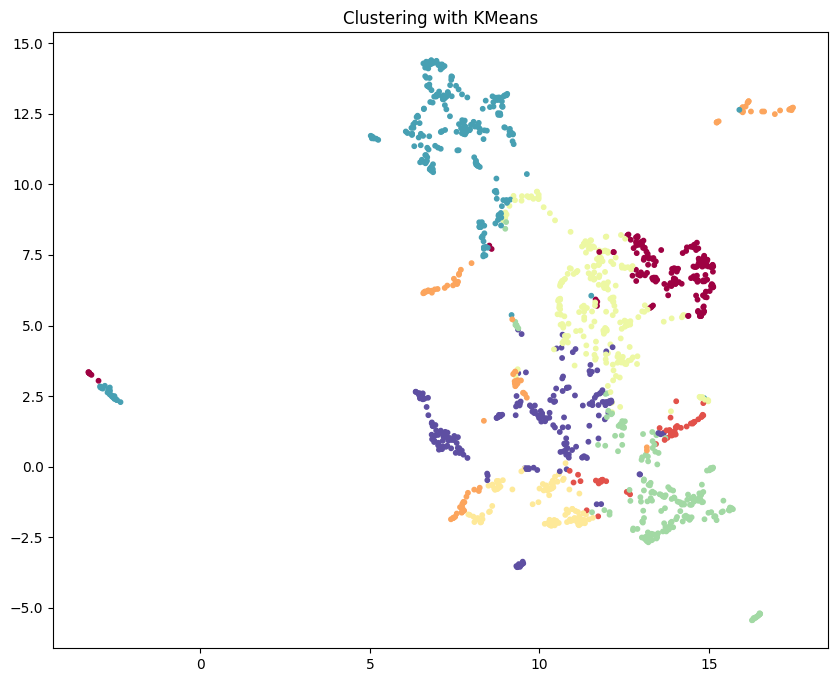

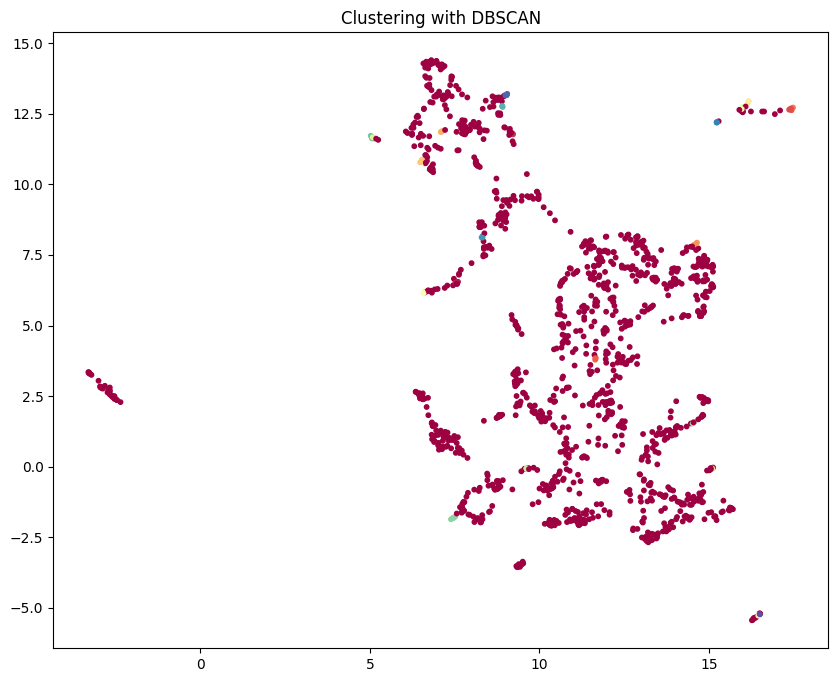

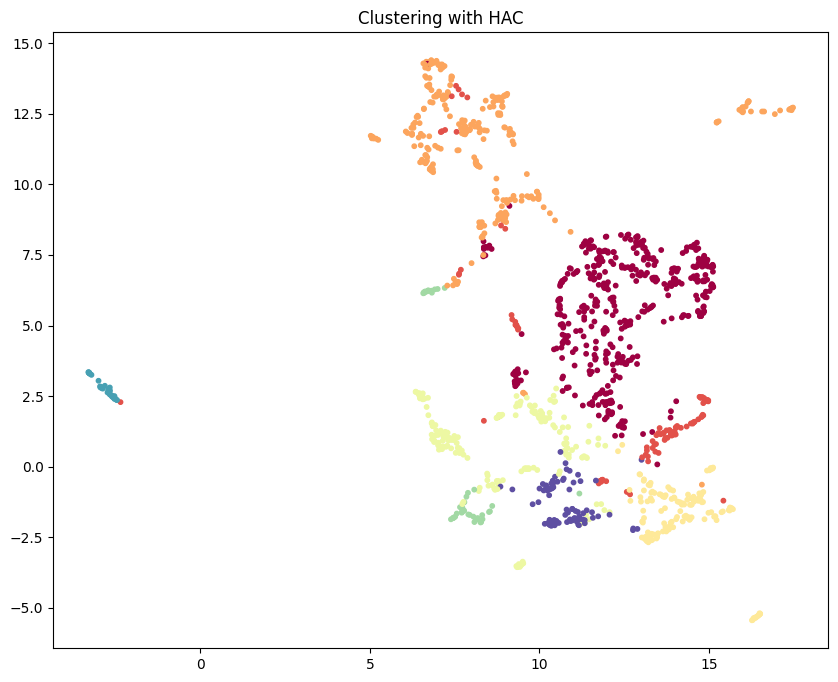

KMeans - Silhouette Score: 0.17
KMeans - Davies-Bouldin Score: 1.66
KMeans - Calinski-Harabasz Index: 260.59
DBSCAN - Silhouette Score: -0.33
DBSCAN - Davies-Bouldin Score: 0.99
DBSCAN - Calinski-Harabasz Index: 4.50
HAC - Silhouette Score: 0.20
HAC - Davies-Bouldin Score: 1.52
HAC - Calinski-Harabasz Index: 245.09


In [12]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors
from rdkit.DataStructs import TanimotoSimilarity, ExplicitBitVect, CreateFromBitString
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
import umap
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import matplotlib.pyplot as plt

# Step 1: Clean and Prepare Dataset
def cleaned(dataframe, min_weight=50, max_weight=1000):
    dataframe = dataframe.dropna(subset=['canonical_smiles']).reset_index(drop=True)
    dataframe['valid'] = dataframe['canonical_smiles'].apply(lambda x: Chem.MolFromSmiles(x) is not None)
    dataframe = dataframe[dataframe['valid']].drop(columns=['valid']).reset_index(drop=True)
    dataframe['canonical_smiles'] = dataframe['canonical_smiles'].apply(lambda x: Chem.MolToSmiles(Chem.MolFromSmiles(x)))
    
    def is_within_range(smiles, min_weight, max_weight):
        mol = Chem.MolFromSmiles(smiles)
        return min_weight <= Descriptors.MolWt(mol) <= max_weight if mol else False

    dataframe = dataframe[dataframe['canonical_smiles'].apply(
        lambda x: is_within_range(x, min_weight, max_weight)
    )].reset_index(drop=True)

    return dataframe

# Step 2: Calculate Molecular Properties
def calculate_properties(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if not mol:
        return {prop: None for prop in [
            "Molecular Weight", "Heavy atoms", "logP", "Refractivity", "TPSA",
            "fraction csp3", "H-Bond Donors", "H-Bond Acceptors", "Rotatable bonds",
            "Num rings", "Aromatic Rings", "Aliphatic_rings", "Stereo centers",
            "Charge", "Valence electrons"]}
    return {
        "Molecular Weight": Descriptors.MolWt(mol),
        "Heavy atoms": Descriptors.HeavyAtomCount(mol),
        "logP": Descriptors.MolLogP(mol),
        "Refractivity": Descriptors.MolMR(mol),
        "TPSA": rdMolDescriptors.CalcTPSA(mol),
        "fraction csp3": rdMolDescriptors.CalcFractionCSP3(mol),
        "H-Bond Donors": Descriptors.NumHDonors(mol),
        "H-Bond Acceptors": Descriptors.NumHAcceptors(mol),
        "Rotatable bonds": Descriptors.NumRotatableBonds(mol),
        "Num rings": rdMolDescriptors.CalcNumRings(mol),
        "Aromatic Rings": rdMolDescriptors.CalcNumAromaticRings(mol),
        "Aliphatic_rings": rdMolDescriptors.CalcNumAliphaticRings(mol),
        "Stereo centers": len(Chem.FindMolChiralCenters(mol, includeUnassigned=True)),
        "Charge": Chem.rdmolops.GetFormalCharge(mol),
        "Valence electrons": Descriptors.NumValenceElectrons(mol),
    }

# Step 3: Process and Save Features and Fingerprints
def process_and_save(dataframe, features_file, fingerprints_file):
    dataframe['features'] = dataframe['canonical_smiles'].apply(calculate_properties)
    features_df = pd.DataFrame(dataframe['features'].tolist())

    dataframe['fingerprints'] = dataframe['canonical_smiles'].apply(
        lambda x: np.array(rdMolDescriptors.GetMorganFingerprintAsBitVect(
            Chem.MolFromSmiles(x), radius=2, nBits=1024))
    )
    fingerprints_df = pd.DataFrame(dataframe['fingerprints'].tolist())

    features_df.to_csv(features_file, index=False)
    fingerprints_df.to_csv(fingerprints_file, index=False)
    print(features_df.head())

    return features_df, fingerprints_df

# Step 4: Scaling and PCA on Features
def scale_and_pca(features_df, n_components=0.95):
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(features_df)
    pca = PCA(n_components=n_components)
    pca_features = pca.fit_transform(scaled_features)
    print(f"PCA components retained: {pca.n_components_}")
    return pca_features

# Step 5: Calculate Tanimoto Distances
def calculate_tanimoto(fingerprints):
    bit_vectors = [CreateFromBitString(''.join(map(str, fp))) for fp in fingerprints]
    n = len(bit_vectors)
    distances = np.zeros((n, n))
    for i in range(n):
        for j in range(i, n):
            distances[i, j] = TanimotoSimilarity(bit_vectors[i], bit_vectors[j])
            distances[j, i] = distances[i, j]
    return distances

# Step 6: Combine Features and Distances
def combine_features(pca_features, tanimoto_distances):
    return np.hstack((pca_features, tanimoto_distances))

# Step 7: Clustering and UMAP Visualization
def perform_clustering(data, n_clusters=8):
    kmeans = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42).fit(data)
    dbscan = DBSCAN(eps=0.5, min_samples=3).fit(data)
    hac = AgglomerativeClustering(n_clusters=n_clusters).fit(data)
    
    labels = {'KMeans': kmeans.labels_, 'DBSCAN': dbscan.labels_, 'HAC': hac.labels_}
    umap_reducer = umap.UMAP(n_neighbors=15, min_dist=0.2, n_components=2, random_state=42)
    umap_data = umap_reducer.fit_transform(data)

    for method, label in labels.items():
        plt.figure(figsize=(10, 8))
        plt.scatter(umap_data[:, 0], umap_data[:, 1], c=label, cmap='Spectral', s=10)
        plt.title(f"Clustering with {method}")
        plt.show()

    return labels

# Step 8: Evaluate Clustering
def evaluate_clustering(data, labels):
    for method, label in labels.items():
        if len(set(label)) > 1:
            sil_score = silhouette_score(data, label)
            db_score = davies_bouldin_score(data, label)
            ch_score = calinski_harabasz_score(data, label)
            print(f"{method} - Silhouette Score: {sil_score:.2f}")
            print(f"{method} - Davies-Bouldin Score: {db_score:.2f}")
            print(f"{method} - Calinski-Harabasz Index: {ch_score:.2f}")
        else:
            print(f"{method} - Only one cluster found.")

# Example Execution
features_file = "features.csv"
fingerprints_file = "fingerprints.csv"

# Define file paths
synthetic_data_path = "/homes/mesmaeili/Documents/DS6/data/non_natural_products.txt"  
natural_data_path = "/homes/mesmaeili/Documents/DS6/data/subset_natural_products.txt"

try:
    # Load the datasets
    synthetic_df = pd.read_csv(synthetic_data_path, sep="\t", engine='python')
    natural_df = pd.read_csv(natural_data_path, sep="\t", engine='python')
    
    # Add a column to indicate source: 1 for synthetic, 0 for natural
    synthetic_df['source'] = 1
    natural_df['source'] = 0
    
    # Combine the datasets
    combined_df = pd.concat([synthetic_df, natural_df], ignore_index=True)
    
    # Display the combined dataset
    print(combined_df.head())
except Exception as e:
    print(f"Error loading or processing files: {e}")

# Process the dataset
cleaned_df = cleaned(combined_df)
features_df, fingerprints_df = process_and_save(cleaned_df, features_file, fingerprints_file)

# Scale and Apply PCA
pca_features = scale_and_pca(features_df)

# Calculate Tanimoto Distances
tanimoto_distances = calculate_tanimoto(fingerprints_df.values)

# Combine Features and Distances
combined_features = combine_features(pca_features, tanimoto_distances)

# Cluster and Visualize
labels = perform_clustering(combined_features)

# Evaluate Clustering
evaluate_clustering(combined_features, labels)



t-SNE completed with 2 components.


/homes/mesmaeili/Documents/myenv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/homes/mesmaeili/Documents/myenv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/homes/mesmaeili/Documents/myenv/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/homes/mesmaeili/Documents/myenv/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "dpi" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figu

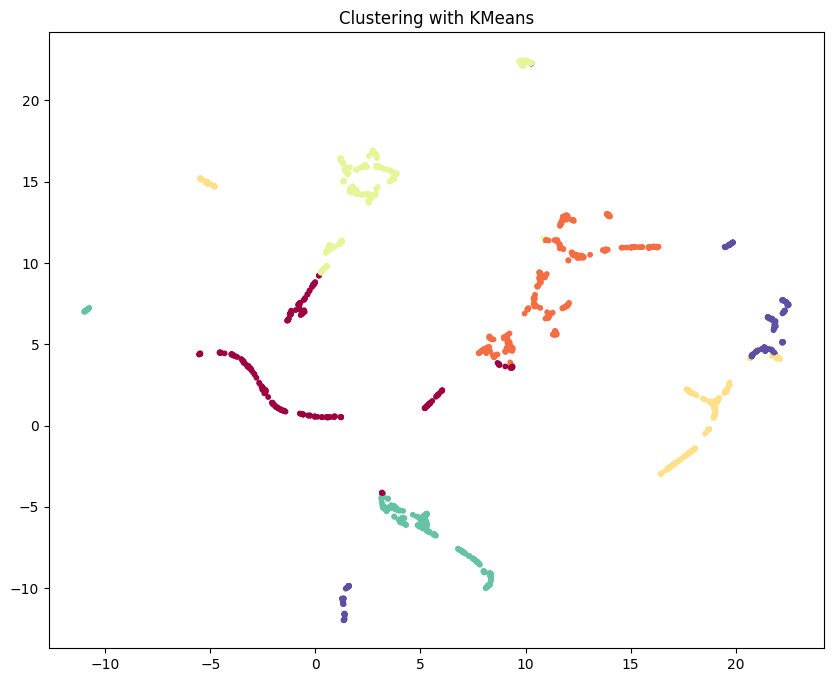

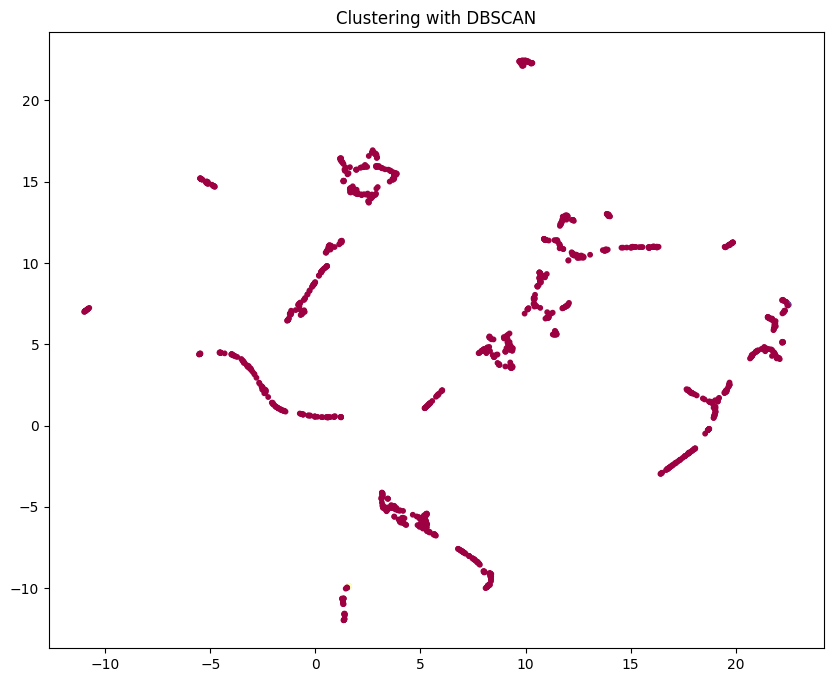

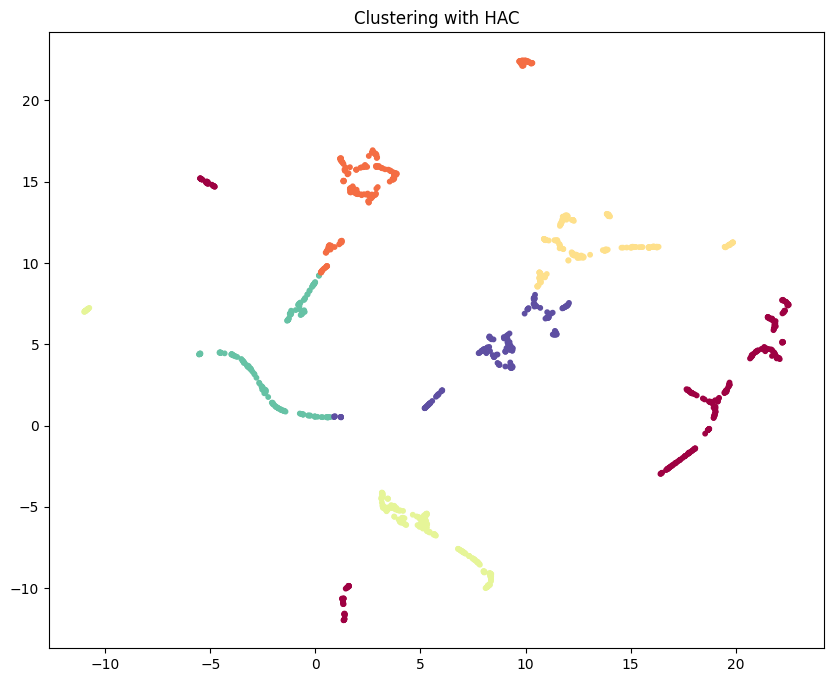

KMeans - Silhouette Score: 0.43
KMeans - Davies-Bouldin Score: 0.78
KMeans - Calinski-Harabasz Index: 1632.29
DBSCAN - Silhouette Score: 0.04
DBSCAN - Davies-Bouldin Score: 0.76
DBSCAN - Calinski-Harabasz Index: 9.85
HAC - Silhouette Score: 0.45
HAC - Davies-Bouldin Score: 0.75
HAC - Calinski-Harabasz Index: 1426.57


In [13]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors
from rdkit.DataStructs import TanimotoSimilarity, ExplicitBitVect, CreateFromBitString
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
import umap
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import matplotlib.pyplot as plt

# Step 1: Clean and Prepare Dataset (Unchanged)
def cleaned(dataframe, min_weight=50, max_weight=1000):
    dataframe = dataframe.dropna(subset=['canonical_smiles']).reset_index(drop=True)
    dataframe['valid'] = dataframe['canonical_smiles'].apply(lambda x: Chem.MolFromSmiles(x) is not None)
    dataframe = dataframe[dataframe['valid']].drop(columns=['valid']).reset_index(drop=True)
    dataframe['canonical_smiles'] = dataframe['canonical_smiles'].apply(lambda x: Chem.MolToSmiles(Chem.MolFromSmiles(x)))
    
    def is_within_range(smiles, min_weight, max_weight):
        mol = Chem.MolFromSmiles(smiles)
        return min_weight <= Descriptors.MolWt(mol) <= max_weight if mol else False

    dataframe = dataframe[dataframe['canonical_smiles'].apply(
        lambda x: is_within_range(x, min_weight, max_weight)
    )].reset_index(drop=True)

    return dataframe

# Step 2: Calculate Molecular Properties (Unchanged)
def calculate_properties(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if not mol:
        return {prop: None for prop in [
            "Molecular Weight", "Heavy atoms", "logP", "Refractivity", "TPSA",
            "fraction csp3", "H-Bond Donors", "H-Bond Acceptors", "Rotatable bonds",
            "Num rings", "Aromatic Rings", "Aliphatic_rings", "Stereo centers",
            "Charge", "Valence electrons"]}
    return {
        "Molecular Weight": Descriptors.MolWt(mol),
        "Heavy atoms": Descriptors.HeavyAtomCount(mol),
        "logP": Descriptors.MolLogP(mol),
        "Refractivity": Descriptors.MolMR(mol),
        "TPSA": rdMolDescriptors.CalcTPSA(mol),
        "fraction csp3": rdMolDescriptors.CalcFractionCSP3(mol),
        "H-Bond Donors": Descriptors.NumHDonors(mol),
        "H-Bond Acceptors": Descriptors.NumHAcceptors(mol),
        "Rotatable bonds": Descriptors.NumRotatableBonds(mol),
        "Num rings": rdMolDescriptors.CalcNumRings(mol),
        "Aromatic Rings": rdMolDescriptors.CalcNumAromaticRings(mol),
        "Aliphatic_rings": rdMolDescriptors.CalcNumAliphaticRings(mol),
        "Stereo centers": len(Chem.FindMolChiralCenters(mol, includeUnassigned=True)),
        "Charge": Chem.rdmolops.GetFormalCharge(mol),
        "Valence electrons": Descriptors.NumValenceElectrons(mol),
    }

# Step 3: Process and Save Features and Fingerprints (Unchanged)
def process_and_save(dataframe, features_file, fingerprints_file):
    dataframe['features'] = dataframe['canonical_smiles'].apply(calculate_properties)
    features_df = pd.DataFrame(dataframe['features'].tolist())

    dataframe['fingerprints'] = dataframe['canonical_smiles'].apply(
        lambda x: np.array(rdMolDescriptors.GetMorganFingerprintAsBitVect(
            Chem.MolFromSmiles(x), radius=2, nBits=1024))
    )
    fingerprints_df = pd.DataFrame(dataframe['fingerprints'].tolist())

    features_df.to_csv(features_file, index=False)
    fingerprints_df.to_csv(fingerprints_file, index=False)

    return features_df, fingerprints_df

# Step 4: Scaling and t-SNE on Features
def scale_and_tsne(features_df, n_components=2, perplexity=30):
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(features_df)
    tsne = TSNE(n_components=n_components, perplexity=perplexity, random_state=42)
    tsne_features = tsne.fit_transform(scaled_features)
    print(f"t-SNE completed with {n_components} components.")
    return tsne_features

# Step 5: Calculate Tanimoto Distances (Unchanged)
def calculate_tanimoto(fingerprints):
    bit_vectors = [CreateFromBitString(''.join(map(str, fp))) for fp in fingerprints]
    n = len(bit_vectors)
    distances = np.zeros((n, n))
    for i in range(n):
        for j in range(i, n):
            distances[i, j] = TanimotoSimilarity(bit_vectors[i], bit_vectors[j])
            distances[j, i] = distances[i, j]
    return distances

# Step 6: Combine Features and Distances (Unchanged)
def combine_features(tsne_features, tanimoto_distances):
    return np.hstack((tsne_features, tanimoto_distances))

# Step 7: Clustering and UMAP Visualization (Unchanged)
def perform_clustering(data, n_clusters=6):
    kmeans = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42).fit(data)
    dbscan = DBSCAN(eps=0.5, min_samples=5).fit(data)
    hac = AgglomerativeClustering(n_clusters=n_clusters).fit(data)
    
    labels = {'KMeans': kmeans.labels_, 'DBSCAN': dbscan.labels_, 'HAC': hac.labels_}
    umap_reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
    umap_data = umap_reducer.fit_transform(data)

    for method, label in labels.items():
        plt.figure(figsize=(10, 8))
        plt.scatter(umap_data[:, 0], umap_data[:, 1], c=label, cmap='Spectral', s=10)
        plt.title(f"Clustering with {method}")
        plt.show()

    return labels

# Step 8: Evaluate Clustering (Unchanged)
def evaluate_clustering(data, labels):
    for method, label in labels.items():
        if len(set(label)) > 1:
            sil_score = silhouette_score(data, label)
            db_score = davies_bouldin_score(data, label)
            ch_score = calinski_harabasz_score(data, label)
            print(f"{method} - Silhouette Score: {sil_score:.2f}")
            print(f"{method} - Davies-Bouldin Score: {db_score:.2f}")
            print(f"{method} - Calinski-Harabasz Index: {ch_score:.2f}")
        else:
            print(f"{method} - Only one cluster found.")

# Example Execution
features_file = "features.csv"
fingerprints_file = "fingerprints.csv"

# Define file paths
synthetic_data_path = "/homes/mesmaeili/Documents/DS6/data/non_natural_products.txt"  
natural_data_path = "/homes/mesmaeili/Documents/DS6/data/subset_natural_products.txt"

try:
    synthetic_df = pd.read_csv(synthetic_data_path, sep="\t", engine='python')
    natural_df = pd.read_csv(natural_data_path, sep="\t", engine='python')
    synthetic_df['source'] = 1
    natural_df['source'] = 0
    combined_df = pd.concat([synthetic_df, natural_df], ignore_index=True)
except Exception as e:
    print(f"Error loading or processing files: {e}")

# Process the dataset
cleaned_df = cleaned(combined_df)
features_df, fingerprints_df = process_and_save(cleaned_df, features_file, fingerprints_file)

# Scale and Apply t-SNE
tsne_features = scale_and_tsne(features_df)

# Calculate Tanimoto Distances
tanimoto_distances = calculate_tanimoto(fingerprints_df.values)

# Combine Features and Distances
combined_features = combine_features(tsne_features, tanimoto_distances)

# Cluster and Visualize
labels = perform_clustering(combined_features)

# Evaluate Clustering
evaluate_clustering(combined_features, labels)
